In [1]:
import os
from dotenv import load_dotenv,find_dotenv

_ = load_dotenv(find_dotenv())

openai_key = os.getenv("OPENAI_API_KEY")


In [2]:
profile = {
    "name":"John",
    "full_name":"John Doe",
    "user_profile_background":"Senior software engineer leading a team of 5 developer",
    }

In [3]:
prompt_instructions={
    "triage_rules":{
        "ignore":"Marketing newsletters,spam emails,mass company announcements",
        "notify":"Team members out sick, build system notifications, project status updates",
        "respond":"Direct questions from team members, meeting requests, critical bug reports",

    },
    "agent_instructions":"Use these tools when appropriate to help manage John's tasks efficiently."
}

In [4]:
email = {
    "from":"Alice Smith <alice.smith@company.com",
    "to":"John Doe<john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "body":"""
Hi John,

I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem missing 
from the specs. Could you help clarify if this was intentional or if we should update the docs?

Specifically, I'm looking at:
- /auth/refresh
- /auth/validate

Thanks!
Alice
""",
}

In [5]:
from pydantic import BaseModel,Field
from typing_extensions import TypedDict,Literal,Annotated
from langchain.chat_models import init_chat_model

In [6]:
llm = init_chat_model("openai:poolside/laguna-m.1:free",
                      base_url="https://openrouter.ai/api/v1",
                      api_key=openai_key)

In [7]:
class Router(BaseModel):
    """Analyze the unread email and route it according to its content."""

    reasoning: str = Field(
        description="Step-by-step reasoning behind the classification."
    )
    classification: Literal["ignore", "respond", "notify"] = Field(
        description="The classification of an email: 'ignore' for irrelevant emails, "
        "'notify' for important information that doesn't need a response, "
        "'respond' for emails that need a reply",
    )

In [8]:
### llm_router always return information in this schema 
llm_router = llm.with_structured_output(Router)

In [9]:
from prompts import triage_system_prompt,triage_user_prompt

In [10]:
system_prompt= triage_system_prompt.format(
    full_name=profile["full_name"],
    name = profile["name"],
    examples=None,
    user_profile_background=profile["user_profile_background"],
    triage_no=prompt_instructions["triage_rules"]["ignore"],
    triage_notify=prompt_instructions["triage_rules"]["notify"],
    triage_email=prompt_instructions["triage_rules"]["respond"],
)

In [11]:
user_prompt = triage_user_prompt.format(
    author=email["from"],
    to=email["to"],
    subject=email["subject"],
    email_thread=email["body"],
)

In [12]:
result = llm_router.invoke(
    [
        {"role":"system","content":system_prompt},
        {"role":"user","content":user_prompt},
    ]
)

In [13]:
print(result)

reasoning="The email is a direct question from a team member (Alice Smith) regarding missing API endpoints in documentation. This falls under 'RESPOND' as it requires John's direct clarification and decision-making on whether to update the docs or confirm the endpoints are intentionally excluded." classification='respond'


In [14]:
from langchain_core.tools import tool

In [15]:
# connect your gmail api
@tool
def write_email(to: str,subject: str,content: str) -> str:
    """write and send an email."""
    return f"Email sent to {to} with subject '{subject}'"

In [16]:
@tool 
def schedule_meeting(
    attendees: list[str],
    subject: str,
    duration_minutes: int,
    preffered_day: str
)-> str:
    """schedule a calender meeting."""
    # IN real app would check calendar and schedule a meeting

    return f" Meeting '{subject}' scheduled for {preffered_day} with '{len(attendees)}' attendees"

In [17]:
@tool
def check_calendar_availability(day: str)-> str:
    """Check calendar availability for a given day."""
    # in real app would check callender
    return f" Available times on {day}: 9:00 AM, 2:00 PM, 4:00 PM"





In [18]:
from prompts import agent_system_prompt

def create_prompt(state):
    return[
        {
            "role": "system",
            "content": agent_system_prompt.format(
                instructions=prompt_instructions["agent_instructions"],
                **profile
            )
        }
    ] + state['messages']

In [19]:
from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="poolside/laguna-m.1:free",
                      base_url="https://openrouter.ai/api/v1",
                      api_key=openai_key)

In [20]:




# dagent = create_react_agent(
#     model=model,
#     tools=tools,
#     prompt=create_prompt  ,        
# )

In [21]:
tools =[write_email,schedule_meeting,check_calendar_availability]

agent = create_agent(
    model=model,
    tools=tools,
    system_prompt=user_prompt,
 )

response_agent = create_agent(
    model=model,
    tools=tools,
    system_prompt=user_prompt,
   
)

In [22]:
response = agent.invoke(
    {"messages": [{
        "role": "user", 
        "content": "what is my availability for tuesday?"
    }]}
)

In [23]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is my availability for tuesday?
================================== Ai Message ==================================
Tool Calls:
  check_calendar_availability (chatcmpl-tool-c6031a58a7fe476daaa362811b6bb039)
 Call ID: chatcmpl-tool-c6031a58a7fe476daaa362811b6bb039
  Args:
    day: tuesday
================================= Tool Message =================================
Name: check_calendar_availability

 Available times on tuesday: 9:00 AM, 2:00 PM, 4:00 PM
================================== Ai Message ==================================


Your availability on Tuesday is at the following times:
- 9:00 AM
- 2:00 PM
- 4:00 PM


In [24]:
response["messages"][-1].pretty_print()

================================== Ai Message ==================================


Your availability on Tuesday is at the following times:
- 9:00 AM
- 2:00 PM
- 4:00 PM


In [25]:
from langgraph.graph import add_messages

class State(TypedDict):
    email_input: dict
    messages: Annotated[list,add_messages]

In [26]:
from langgraph.graph import StateGraph,START,END
from langgraph.types import Command
from typing import Literal
from IPython.display import Image,display

In [27]:
def triage_router(state: State) -> Command[
    Literal["response_agent", "__end__"]
]:
    author = state['email_input']['author']
    to = state['email_input']['to']
    subject = state['email_input']['subject']
    email_thread = state['email_input']['email_thread']

    system_prompt = triage_system_prompt.format(
        full_name=profile["full_name"],
        name=profile["name"],
        user_profile_background=profile["user_profile_background"],
        triage_no=prompt_instructions["triage_rules"]["ignore"],
        triage_notify=prompt_instructions["triage_rules"]["notify"],
        triage_email=prompt_instructions["triage_rules"]["respond"],
        examples=None
    )
    user_prompt = triage_user_prompt.format(
        author=author, 
        to=to, 
        subject=subject, 
        email_thread=email_thread
    )
    result = llm_router.invoke(
        [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
    )
    if result.classification == "respond":
        print("📧 Classification: RESPOND - This email requires a response")
        goto = "response_agent"
        update = {
            "messages": [
                {
                    "role": "user",
                    "content": f"Respond to the email {state['email_input']}",
                }
            ]
        }
    elif result.classification == "ignore":
        print("🚫 Classification: IGNORE - This email can be safely ignored")
        update = None
        goto = END
    elif result.classification == "notify":
        # If real life, this would do something else
        print("🔔 Classification: NOTIFY - This email contains important information")
        update = None
        goto = END
    else:
        raise ValueError(f"Invalid classification: {result.classification}")
    return Command(goto=goto, update=update)

In [28]:
email_agent = StateGraph(State)
email_agent = email_agent.add_node(triage_router)
email_agent = email_agent.add_node("response_agent", agent)
email_agent = email_agent.add_edge(START, "triage_router")
email_agent = email_agent.compile()

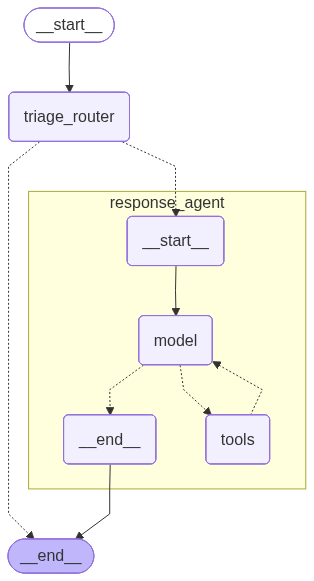

In [29]:
# Show the agent
display(Image(email_agent.get_graph(xray=True).draw_mermaid_png()))

In [30]:
email_input = {
    "author": "Marketing Team <marketing@amazingdeals.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "🔥 EXCLUSIVE OFFER: Limited Time Discount on Developer Tools! 🔥",
    "email_thread": """Dear Valued Developer,

Don't miss out on this INCREDIBLE opportunity! 

🚀 For a LIMITED TIME ONLY, get 80% OFF on our Premium Developer Suite! 

✨ FEATURES:
- Revolutionary AI-powered code completion
- Cloud-based development environment
- 24/7 customer support
- And much more!

💰 Regular Price: $999/month
🎉 YOUR SPECIAL PRICE: Just $199/month!

🕒 Hurry! This offer expires in:
24 HOURS ONLY!

Click here to claim your discount: https://amazingdeals.com/special-offer

Best regards,
Marketing Team
---
To unsubscribe, click here
""",
}

In [31]:
response = email_agent.invoke({"email_input": email_input})

🚫 Classification: IGNORE - This email can be safely ignored


In [32]:
email_input = {
    "author": "Alice Smith <alice.smith@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "email_thread": """Hi John,

I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?

Specifically, I'm looking at:
- /auth/refresh
- /auth/validate

Thanks!
Alice""",
}

In [33]:
response = email_agent.invoke({"email_input": email_input})

📧 Classification: RESPOND - This email requires a response


In [34]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Respond to the email {'author': 'Alice Smith <alice.smith@company.com>', 'to': 'John Doe <john.doe@company.com>', 'subject': 'Quick question about API documentation', 'email_thread': "Hi John,\n\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\n\nSpecifically, I'm looking at:\n- /auth/refresh\n- /auth/validate\n\nThanks!\nAlice"}
================================== Ai Message ==================================


I'll help you respond to Alice's email. Let me draft a reply to clarify the status of those endpoints.
Tool Calls:
  write_email (chatcmpl-tool-025d1f35003a49e387787cc9359a3cfc)
 Call ID: chatcmpl-tool-025d1f35003a49e387787cc9359a3cfc
  Args:
    to: alice.smith@company.com
    subject: Re: Quick question about API documentation
    